<a href="https://colab.research.google.com/github/Eyezesco/BigFoot_Sighting_Density_in_the_U.S./blob/main/Subscription_SaaS_%26_Media_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import os

# Clean up any existing lock file
if os.path.exists('saas_churn.db'):
    os.remove('saas_churn.db')

# 1. Connect to SQLite database
conn = sqlite3.connect('saas_churn.db')
cursor = conn.cursor()

# 2. Create Tables
cursor.execute('''
CREATE TABLE IF NOT EXISTS plans (
    plan_id INTEGER PRIMARY KEY,
    plan_name TEXT,
    monthly_price REAL
)''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS users (
    user_id INTEGER PRIMARY KEY,
    plan_id INTEGER,
    signup_date TEXT,
    tenure_months INTEGER,
    FOREIGN KEY(plan_id) REFERENCES plans(plan_id)
)''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS user_activity (
    activity_id INTEGER PRIMARY KEY,
    user_id INTEGER,
    logins_last_30_days INTEGER,
    support_tickets_count INTEGER,
    billing_issues_count INTEGER,
    is_churned INTEGER, -- 0 for active, 1 for canceled subscription
    FOREIGN KEY(user_id) REFERENCES users(user_id)
)''')

# 3. Generate Realistic Mock Data
rng = np.random.default_rng(555)
n_plans = 3
n_users = 2500

# Insert Subscription Plans
plans_data = [
    (1, 'Basic Tier', 9.99),
    (2, 'Pro Tier', 29.99),
    (3, 'Enterprise Tier', 99.99)
]
cursor.executemany("INSERT INTO plans VALUES (?, ?, ?)", plans_data)

# Insert Users and Activity Logs
users_data = []
activity_data = []

for u_id in range(1, n_users + 1):
    plan_id = int(rng.choice([1, 2, 3], p=[0.6, 0.3, 0.1]))
    tenure = int(rng.integers(1, 36))
    signup_date = f"2024-{rng.integers(1, 13):02d}-01"

    users_data.append((u_id, plan_id, signup_date, tenure))

    # Activity logic: fewer logins and higher support tickets increase churn risk
    logins = int(rng.integers(0, 30))
    tickets = int(rng.integers(0, 6))
    billing_issues = int(rng.choice([0, 1, 2], p=[0.8, 0.15, 0.05]))

    # Churn probability calculation
    churn_prob = 0.4 if (logins < 5 or tickets > 3 or billing_issues > 0) else 0.05
    is_churn = int(rng.choice([0, 1], p=[1 - churn_prob, churn_prob]))

    activity_data.append((
        u_id, u_id, logins, tickets, billing_issues, is_churn
    ))

cursor.executemany("INSERT INTO users VALUES (?, ?, ?, ?)", users_data)
cursor.executemany("INSERT INTO user_activity VALUES (?, ?, ?, ?, ?, ?)", activity_data)
conn.commit()

# Verify load
df_saas_check = pd.read_sql("SELECT * FROM user_activity LIMIT 5", conn)
print("SaaS Churn Database setup complete! Here are your first 5 user activity records:")
display(df_saas_check)

SaaS Churn Database setup complete! Here are your first 5 user activity records:


,activity_id,user_id,logins_last_30_days,support_tickets_count,billing_issues_count,is_churned
0,1,1,25,0,0,0
1,2,2,19,4,1,0
2,3,3,8,0,2,0
3,4,4,2,4,0,0
4,5,5,15,2,1,0


In [ ]:
import sqlite3
import pandas as pd

# Connect to SaaS database
conn = sqlite3.connect('saas_churn.db')

# SQL Query analyzing churn rates and activity metrics across subscription tiers
saas_query = '''
SELECT
    p.plan_name,
    p.monthly_price,
    COUNT(u.user_id) AS total_users,
    ROUND(AVG(ua.logins_last_30_days), 1) AS avg_monthly_logins,
    ROUND(AVG(ua.support_tickets_count), 1) AS avg_support_tickets,
    SUM(ua.is_churned) AS total_churned_users,
    ROUND(SUM(ua.is_churned) * 100.0 / COUNT(u.user_id), 1) AS churn_rate_pct
FROM users u
JOIN plans p ON u.plan_id = p.plan_id
JOIN user_activity ua ON u.user_id = ua.user_id
GROUP BY p.plan_name, p.monthly_price
ORDER BY churn_rate_pct DESC
'''

# Load into DataFrame
df_saas_analysis = pd.read_sql(saas_query, conn)

print("SaaS churn analysis complete! Here is the breakdown by subscription plan:")
display(df_saas_analysis)

SaaS churn analysis complete! Here is the breakdown by subscription plan:


,plan_name,monthly_price,total_users,avg_monthly_logins,avg_support_tickets,total_churned_users,churn_rate_pct
0,Enterprise Tier,99.99,248,14.5,2.9,64,25.8
1,Pro Tier,29.99,781,15.0,2.5,192,24.6
2,Basic Tier,9.99,1471,14.4,2.4,359,24.4


--- SaaS Churn Tier Summary ---


,plan_name,total_users,churn_rate_pct
0,Enterprise Tier,248,25.8
1,Pro Tier,781,24.6
2,Basic Tier,1471,24.4


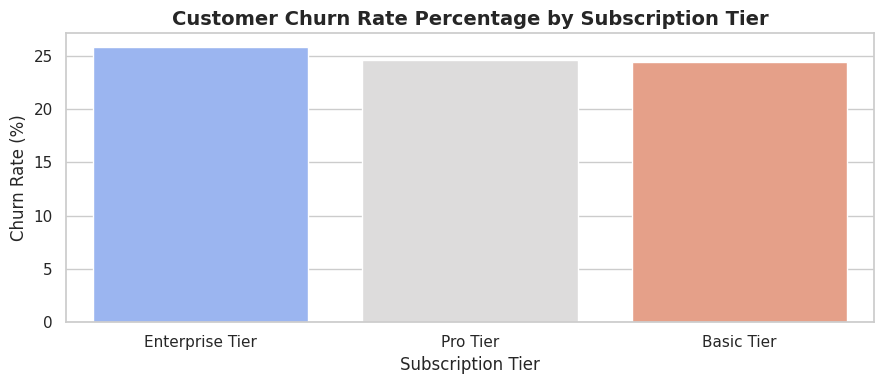

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- SaaS Churn Tier Summary ---")
display(df_saas_analysis[['plan_name', 'total_users', 'churn_rate_pct']])

# Visualize Churn Rate by Plan
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 4))

ax = sns.barplot(
    data=df_saas_analysis,
    x='plan_name',
    y='churn_rate_pct',
    palette='coolwarm',
    hue='plan_name',
    legend=False
)

plt.title('Customer Churn Rate Percentage by Subscription Tier', fontsize=14, fontweight='bold')
plt.xlabel('Subscription Tier', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.tight_layout()

plt.show()